In [15]:
%reload_ext autoreload
%autoreload 2

## Training folds

In [210]:
import csv
import pandas as pd

fold_path = "data/single/data_french/folds_0_train.tsv"
pd.read_csv(fold_path, sep='\t', skip_blank_lines=True,
                           #encoding='utf-8', engine='python', quoting=csv.QUOTE_NONE,
                           names=['Document', 'Sentence-Token', 'Chars', 'Word', 'Tag', 'Empty'], header=None)

,Document,Sentence-Token,Chars,Word,Tag,Empty
0,/080F/annotation.tsv,3-1,257-264,Suivant,O,NaN
1,/080F/annotation.tsv,3-2,265-275,Hippocrate,O,NaN
2,/080F/annotation.tsv,3-3,275-276,",",O,NaN
3,/080F/annotation.tsv,3-4,277-280,les,O,NaN
4,/080F/annotation.tsv,3-5,281-285,vins,B-Smell_Source,NaN
...,...,...,...,...,...,...
10453,/0017F/annotation.tsv,20-8,3970-3979,fait-elle,O,NaN
10454,/0017F/annotation.tsv,20-9,3980-3987,oublier,O,NaN
10455,/0017F/annotation.tsv,20-10,3988-3993,votre,O,NaN
10456,/0017F/annotation.tsv,20-11,3994-4005,coquetterie,O,NaN


In [211]:
import evaluate
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import DataCollatorForTokenClassification, AutoConfig
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

from torch import cuda


In [212]:
device = 'cpu'
if cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)



mps


In [214]:
data_dir = 'data_updated/'
language = 'dutch'
model_checkpoint = "models/finetuned/single/dutch/GysBERT-dutch-fold-1-train_size-1.0/"

model_name = model_checkpoint.split('/')[-1]

config = AutoConfig.from_pretrained(model_checkpoint)
labels_to_ids = config.label2id
ids_to_labels = config.id2label


metric = evaluate.load("seqeval")

In [215]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
data_collator = DataCollatorForTokenClassification(tokenizer)

In [216]:
m = AutoModelForTokenClassification.from_pretrained(model_checkpoint, config=config)
m.to(device)
trainer = Trainer(m, data_collator=data_collator, processing_class=tokenizer)

accelerator.py - creating Accelerator instance with args: {'deepspeed_plugin': None, 'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True}
	self.accelerator.state.mixed_precision: no


In [217]:
from train_single import read_split_fold, tokenize_and_align_labels

fold = 1
test, _, _ = read_split_fold(data_dir=data_dir, split="test", label_dict=labels_to_ids, lang=language, fold=fold)
test_dataset = Dataset.from_pandas(test, split="test")
tokenized_test = test_dataset.map(lambda x: tokenize_and_align_labels(x, tokenizer),
                                  batched=True)


mps
Reading fold data_updated//data_dutch/folds_1_test.tsv
Number of tags: 21
Tag
O                   70114
I-Circumstances       644
B-Smell_Source        387
I-Effect              342
B-Smell_Word          340
I-Smell_Source        338
B-Quality             173
I-Location            163
B-Circumstances       104
I-Evoked_Odorant       93
I-Time                 76
I-Odour_Carrier        68
B-Effect               59
B-Location             58
B-Odour_Carrier        56
B-Evoked_Odorant       51
B-Perceiver            51
I-Quality              50
I-Perceiver            34
B-Time                 26
I-Smell_Word            6
Name: count, dtype: int64
Number of unique sentences: 2604


Map:   0%|          | 0/2604 [00:00<?, ? examples/s]

In [244]:
labels_to_ids

{'B-Circumstances': 4,
 'B-Effect': 9,
 'B-Evoked_Odorant': 14,
 'B-Location': 7,
 'B-Odour_Carrier': 11,
 'B-Perceiver': 16,
 'B-Quality': 2,
 'B-Smell_Source': 1,
 'B-Smell_Word': 3,
 'B-Time': 18,
 'I-Circumstances': 5,
 'I-Effect': 10,
 'I-Evoked_Odorant': 15,
 'I-Location': 8,
 'I-Odour_Carrier': 12,
 'I-Perceiver': 19,
 'I-Quality': 13,
 'I-Smell_Source': 6,
 'I-Smell_Word': 17,
 'I-Time': 20,
 'O': 0}

In [219]:
sent = ' '.join(test_dataset[0]['sentence'])
len(tokenizer.tokenize(sent))

95

In [220]:
predictions, labels, _ = trainer.predict(tokenized_test)


/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


The predictions have a distribution of 'likelihood'-like scores per smell category: 

In [224]:
predictions.shape

(2604, 338, 21)

There are 2604 text chunks, with 338 tokens per chunk (padded, because most chunks are shorter than 338) and 21 scores per tokens.

In [243]:
predictions[2][12]


array([ 3.2023418 ,  0.4885341 ,  0.7443857 ,  7.177736  , -2.1994972 ,
       -0.63721716, -0.379158  , -0.9418595 , -2.0379403 , -1.1390797 ,
       -0.96781737,  0.03353993, -0.59832597, -0.495288  , -0.30990386,
        0.103106  , -2.2472713 , -0.06840948, -1.7753232 , -1.5507526 ,
       -2.1132967 ], dtype=float32)

For the 13th token (at index 12) in the third text chunk (at index 2), the fourth category is the most likely, but the first category also has a high score ('O').

In [233]:
predictions.shape
# this is where the distributions are mapped to the category with the maximum score
predictions_bin = np.argmax(predictions, axis=2)

In [246]:
predictions_bin[2][12], ids_to_labels[predictions_bin[2][12]]

(np.int64(3), 'B-Smell_Word')

In [247]:
import pandas as pd

rows = []

for idx, batch in enumerate(tokenized_test):
    batch_preds = predictions_bin[idx][:len(batch['labels'])]
    prev_id = None
    #print(batch['Document'], batch['Num'], batch['sentence'])
    for pred, label, word_id in zip(batch_preds, batch['labels'], batch['word_ids']):
        if word_id is None:
            continue
        if word_id == prev_id:
            continue
        row = {
            'text_id': batch['Document'],
            'sent_idx': batch['Num'],
            'token_idx': word_id+1,
            'token': batch['sentence'][word_id],
            'label': ids_to_labels[label],
            'pred': ids_to_labels[pred],
        }
        rows.append(row)
        prev_id = word_id
    
pd.DataFrame(rows)

,text_id,sent_idx,token_idx,token,label,pred
0,FEMKE_NL_LIT_1568_noot001bosk01_01_txtab_poten...,1,1,bat,O,O
1,FEMKE_NL_LIT_1568_noot001bosk01_01_txtab_poten...,1,2,.,O,O
2,FEMKE_NL_LIT_1568_noot001bosk01_01_txtab_poten...,1,3,313,O,O
3,FEMKE_NL_LIT_1568_noot001bosk01_01_txtab_poten...,1,4,Ghy,O,O
4,FEMKE_NL_LIT_1568_noot001bosk01_01_txtab_poten...,1,5,en,O,O
...,...,...,...,...,...,...
73224,textJosephine_DAmboinscheRariteitkamer_am_pote...,10,31,strand,O,O
73225,textJosephine_DAmboinscheRariteitkamer_am_pote...,10,32,over,O,O
73226,textJosephine_DAmboinscheRariteitkamer_am_pote...,10,33,",",O,O
73227,textJosephine_DAmboinscheRariteitkamer_am_pote...,10,34,ontdekt,O,O


In [248]:
preds = np.argmax(predictions, axis=2)


In [249]:
test_predictions = [
    [ids_to_labels[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(preds, labels)
]
test_labels = [
    [ids_to_labels[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(preds, labels)
]

In [250]:
len(test_predictions)

2604

In [256]:
tokenized_test[0].keys()
print(tokenized_test[0]['word_ids'])

[None, 0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 8, 8, 9, 10, 10, 10, 11, 11, 12, 12, 12, 13, 14, 15, 16, 17, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 27, 28, 29, 30, 31, 32, 33, 34, 35, 35, 35, 36, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 51, 52, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 64, 65, 66, 67, 68, 69, 70, 70, 70, 71, 72, 73, 73, 74, 75, None]


In [257]:
results = metric.compute(predictions=test_predictions, references=test_labels)

In [258]:
results
for label in sorted(results):
    if label.startswith("overall_"):
        results[label] = float(results[label])
        continue
    print(label)
    for measure in results[label]:
        if isinstance(results[label][measure], np.float64):
            results[label][measure] = float(results[label][measure])
        elif isinstance(results[label][measure], np.int64):
            results[label][measure] = int(results[label][measure])

results

Circumstances
Effect
Evoked_Odorant
Location
Odour_Carrier
Perceiver
Quality
Smell_Source
Smell_Word
Time


{'Circumstances': {'precision': 0.08928571428571429,
  'recall': 0.04310344827586207,
  'f1': 0.05813953488372094,
  'number': 116},
 'Effect': {'precision': 0.04225352112676056,
  'recall': 0.039473684210526314,
  'f1': 0.04081632653061224,
  'number': 76},
 'Evoked_Odorant': {'precision': 0.20754716981132076,
  'recall': 0.1506849315068493,
  'f1': 0.17460317460317462,
  'number': 73},
 'Location': {'precision': 0.16666666666666666,
  'recall': 0.01639344262295082,
  'f1': 0.02985074626865672,
  'number': 61},
 'Odour_Carrier': {'precision': 0.1111111111111111,
  'recall': 0.009615384615384616,
  'f1': 0.01769911504424779,
  'number': 104},
 'Perceiver': {'precision': 0.10714285714285714,
  'recall': 0.05172413793103448,
  'f1': 0.0697674418604651,
  'number': 58},
 'Quality': {'precision': 0.563953488372093,
  'recall': 0.6466666666666666,
  'f1': 0.6024844720496894,
  'number': 300},
 'Smell_Source': {'precision': 0.3044189852700491,
  'recall': 0.31155778894472363,
  'f1': 0.30794

## Analyse tokenisers

In [83]:
preds[2]
for idx in range(len(test_dataset)):
    sent_tokens = test_dataset[idx]['sentence']
    sent_text = ' '.join(sent_tokens)
    tokenised_sent = tokenizer.tokenize(sent_text)
    print(tokenised_sent)
    sent_preds = test_predictions[idx]
    
    print(len(sent), len(sent_preds))
    if idx > 4:
        break

['sneeuw', '##ith', 'is', 'hier', 'ghe', '##ble', '##ken', ',', '5', '6', 'die', 'na', 'gods', 'stadt', 'vl', '##ogh', '##e', 'also', 'my', 'docht', '##e', '.', '7', 'en', 'sing', '##ende', 'een', 'soet', 'ghel', '##uyt', 'daer', 'wr', '##ochte', ',', '8', 'en', 'is', 'soo', 'vast', 'met', 'den', 'roo', '##ck', 'opg', '##hes', '##trek', '##en', '.']
120 48
['van', 'dit', 'schoon', 'vier', 'gau', '##en', 'de', 'lichte', 'stralen', '10', '10', 'duy', '##sen', '##t', 'vlammen', 'lust', '##ich', 'in', 'alle', 'palen', ',', '11', 'als', 'dl', '##eken', 'van', 'eenen', 'reg', '##hen', 'van', 'gou', '##we', '12', 'tv', '##ier', 'bl', '##usschen', 'quam', ':', 'o', 'hitte', 'nv', 'maer', 'cou', '##we', '!']
120 46
['dat', 'te', 'voren', 'goeden', 'reu', '##ck', 'heeft', 'ghe', '##ghe', '##uen', ',', 'is', 'nv', 'el', '##aes', 'maer', 'vu', '##ylen', 'stan', '##ck', 'ghe', '##ble', '##uen', '!']
120 24
['du', 'bell', '##ay', '.']
120 4
['dessus', 'vn', 'mont', 'vn', '##e', 'flam', '##me', 'all'

## Analyse spans

In [162]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
from hist_smell.evaluation.near_misses import read_pred_file

multi_test_file = 'test-files-mt-all-lang/out-fold-smell-en/folds_2_test.tsv'
multi_pred_file = 'multitask/predictions-mt/predictions-en/2_prediction.tsv'
pred_tokens = list(read_pred_file(multi_pred_file))
test_tokens = list(read_pred_file(multi_test_file))
len(test_tokens), len(pred_tokens)

(21548, 21548)

In [165]:
from hist_smell.evaluation.near_misses import tokens_to_spans

pred_spans = []
test_spans = []
pred_spans = tokens_to_spans(pred_tokens)
test_spans = tokens_to_spans(test_tokens)

len(tokens), len(test_spans), len(pred_spans)

(24144, 621, 600)

In [166]:
test_spans[:20]
test_spans[1].label
test_spans[1].string
test_spans[1].__dict__

{'text_id': '/067E/annotation.tsv',
 'sent_idx': 12,
 'start': 13,
 'end': 16,
 'text': 'bitch ’ s',
 'label': 'Smell_Source'}

In [167]:
test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
test_freq = test_df.label.value_counts().rename('test_freq')
pred_freq = pred_df.label.value_counts().rename('pred_freq')
test_freq

label
Smell_Source      226
Quality           181
Perceiver          58
Odour_Carrier      48
Circumstances      34
Location           33
Time               19
Effect             15
Evoked_Odorant      7
Name: test_freq, dtype: int64

In [168]:
test_df[test_df.text.str.contains(' ')]
test_df

,text_id,sent_idx,start,end,text,label
0,/067E/annotation.tsv,12,5,6,this,Smell_Source
1,/067E/annotation.tsv,12,13,16,bitch ’ s,Smell_Source
2,/048E/annotation.tsv,16,11,14,of the engines,Smell_Source
3,/008E/annotation.tsv,133,1,3,COSTUS DULCIS,Smell_Source
4,/008E/annotation.tsv,134,1,3,JUNEUS ODORATUS,Smell_Source
...,...,...,...,...,...,...
616,/006E/annotation.tsv,171,20,23,during the summer,Time
617,/016E/annotation.tsv,43,16,17,nowadays,Time
618,/028E/annotation.tsv,20,64,69,at one time than another,Time
619,/052E/annotation.tsv,32,1,4,After twenty-four hours,Time


In [169]:
pred_df

,text_id,sent_idx,start,end,text,label
0,/008E/annotation.tsv,133,1,3,COSTUS DULCIS,Smell_Source
1,/008E/annotation.tsv,133,7,8,Root,Smell_Source
2,/008E/annotation.tsv,134,1,3,JUNEUS ODORATUS,Smell_Source
3,/008E/annotation.tsv,135,5,6,Reed,Smell_Source
4,/008E/annotation.tsv,147,4,5,Sagapenum,Smell_Source
...,...,...,...,...,...,...
595,/028E/annotation.tsv,20,64,67,at one time,Time
596,/028E/annotation.tsv,23,151,152,in,Time
597,/052E/annotation.tsv,32,1,4,After twenty-four hours,Time
598,/020E/annotation.tsv,26,42,43,sometimes,Time


In [170]:
labels = list(test_df.label.unique())

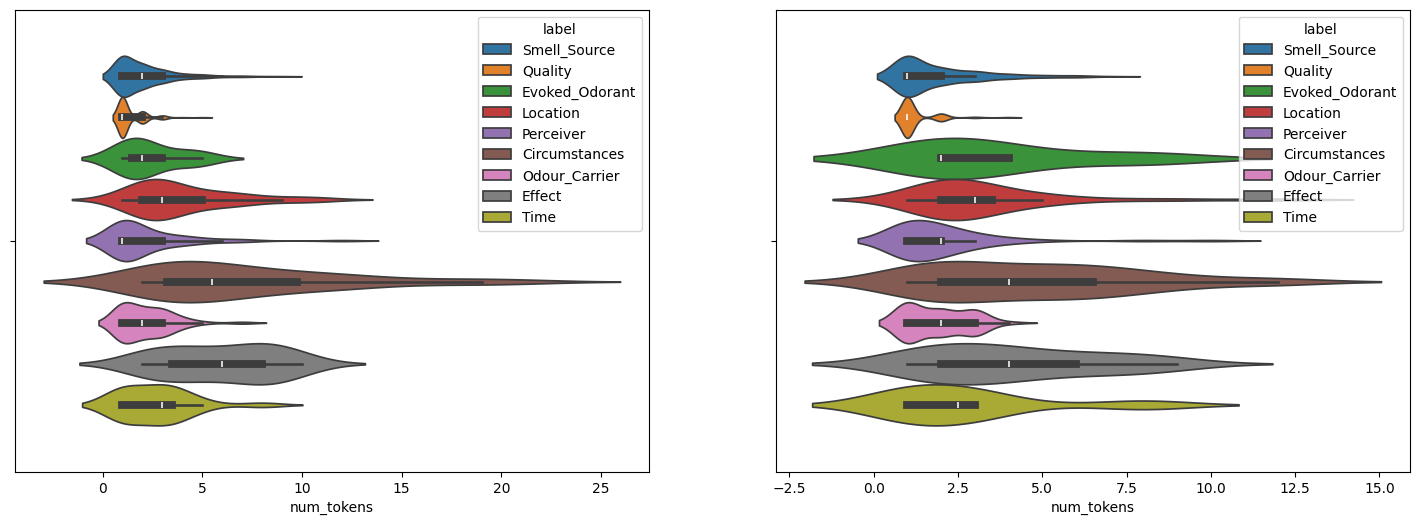

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2)

test_df['num_tokens'] = test_df.apply(lambda row: row['end'] - row['start'], axis=1)
pred_df['num_tokens'] = pred_df.apply(lambda row: row['end'] - row['start'], axis=1)
test_df.groupby('label').num_tokens.describe()
sns.violinplot(test_df, x='num_tokens', hue='label', hue_order=labels, ax=ax[0])
sns.violinplot(pred_df, x='num_tokens', hue='label', hue_order=labels, ax=ax[1])
fig.set_size_inches(18, 6)

In [172]:
from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe

overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
print(len(overlapping_spans), len(test_spans), len(pred_spans))

overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
overlap_df

833 621 600


,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end
0,/001E/annotation.tsv,21.0,2.0,3.0,shrubs,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed
1,/001E/annotation.tsv,21.0,4.0,5.0,those,Smell_Source,/001E/annotation.tsv,21.0,4.0,5.0,those,Smell_Source,exact,exact,exact
2,/001E/annotation.tsv,21.0,12.0,15.0,the hardy Heaths,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed
3,/001E/annotation.tsv,21.0,7.0,9.0,very strong,Quality,/001E/annotation.tsv,21.0,7.0,9.0,very strong,Quality,exact,exact,exact
4,/001E/annotation.tsv,21.0,18.0,21.0,the more pleasant,Quality,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,/085E/annotation.tsv,7.0,9.0,12.0,conforting the spirits,Effect,/085E/annotation.tsv,7.0,9.0,12.0,conforting the spirits,Effect,exact,exact,exact
829,/085E/annotation.tsv,8.0,1.0,6.0,Iuly flowers of the wall,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed
830,/085E/annotation.tsv,8.0,8.0,10.0,wall-Iuly-flowers wall-flowers,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed
831,/085E/annotation.tsv,8.0,12.0,13.0,Bee-flowers,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed


In [208]:
overlap_df[overlap_df.match_type == 'partial']

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end
62,FEMKE_NL_SCIENCE_1720_Nieuwentijt_nieu030regt0...,5.0,19.0,25.0,de gansche lugt soude besmet werden,Effect,FEMKE_NL_SCIENCE_1720_Nieuwentijt_nieu030regt0...,5.0,19.0,24.0,de gansche lugt soude besmet,Effect,partial,exact,early
66,FEMKE_NL_SCIENCE_1720_Nieuwentijt_nieu030regt0...,6.0,27.0,29.0,hert verquikkende,Quality,FEMKE_NL_SCIENCE_1720_Nieuwentijt_nieu030regt0...,6.0,28.0,29.0,verquikkende,Quality,partial,late,exact
73,FEMKE_NL_SCIENCE_1720_Nieuwentijt_nieu030regt0...,7.0,5.0,8.0,"de rievieren ,",Smell_Source,FEMKE_NL_SCIENCE_1720_Nieuwentijt_nieu030regt0...,7.0,6.0,7.0,rievieren,Smell_Source,partial,late,early
83,FEMKE_NL_SCIENCE_1737_Swammerdam_swam001bybe01...,9.0,4.0,6.0,gebrant synde,Circumstances,FEMKE_NL_SCIENCE_1737_Swammerdam_swam001bybe01...,9.0,2.0,6.0,dit Deksel gebrant synde,Circumstances,partial,early,exact
88,FEMKE_NL_SCIENCE_1769_1771_berkhey2_fran011nat...,8.0,66.0,68.0,sterken aardagtigen,Quality,FEMKE_NL_SCIENCE_1769_1771_berkhey2_fran011nat...,8.0,66.0,67.0,sterken,Quality,partial,exact,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,Smytegelt_potentially_smelly_passages_56,2.0,13.0,19.0,komt hij dikwijls weer tot zichzelf,Effect,Smytegelt_potentially_smelly_passages_56,2.0,14.0,15.0,hij,Effect,partial,late,early
1254,Smytegelt_potentially_smelly_passages_56,2.0,13.0,19.0,komt hij dikwijls weer tot zichzelf,Effect,Smytegelt_potentially_smelly_passages_56,2.0,15.0,19.0,dikwijls weer tot zichzelf,Effect,partial,late,exact
1270,textJosephine_DAmboinscheRariteitkamer_al_pote...,4.0,69.0,71.0,veel kragtiger,Quality,textJosephine_DAmboinscheRariteitkamer_al_pote...,4.0,70.0,71.0,kragtiger,Quality,partial,late,exact
1272,textJosephine_DAmboinscheRariteitkamer_al_pote...,4.0,54.0,59.0,of eigentlyk naar Unguis Odoratus,Evoked_Odorant,textJosephine_DAmboinscheRariteitkamer_al_pote...,4.0,56.0,59.0,naar Unguis Odoratus,Evoked_Odorant,partial,late,exact


In [173]:
overlap_df[overlap_df.match_type == 'partial'].groupby('overlap_start').overlap_end.value_counts().unstack()

overlap_end,early,exact,late
overlap_start,,,
early,3.0,8.0,2.0
exact,28.0,NaN,6.0
late,5.0,27.0,2.0


In [174]:
overlap_df.groupby('overlap_start').overlap_end.value_counts().unstack()

overlap_end,early,exact,late,missed,wrong
overlap_start,,,,,
early,3.0,8.0,2.0,NaN,NaN
exact,28.0,322.0,6.0,NaN,NaN
late,5.0,27.0,2.0,NaN,NaN
missed,NaN,NaN,NaN,229.0,NaN
wrong,NaN,NaN,NaN,NaN,201.0


<Axes: xlabel='value', ylabel='Density'>

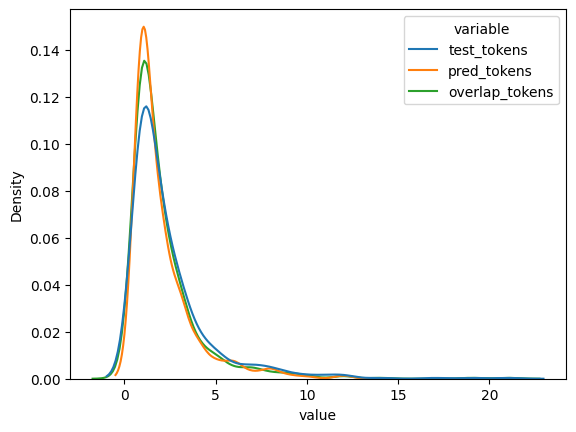

In [175]:
import seaborn as sns

overlap_df['test_tokens'] = overlap_df.apply(lambda row: row['test_end'] - row['test_start'], axis=1)
overlap_df['pred_tokens'] = overlap_df.apply(lambda row: row['pred_end'] - row['pred_start'], axis=1)
overlap_df['overlap_tokens'] = overlap_df.apply(lambda row: min(row['test_end'], row['pred_end']) - max(row['test_start'], row['pred_start']), axis=1)
#sns.histplot(overlap_df, x='test_start')
sns.kdeplot(overlap_df[['test_tokens', 'pred_tokens', 'overlap_tokens']].melt(), x='value', hue='variable')

In [176]:
overlap_df.match_type.value_counts()

match_type
exact        322
miss_pred    229
miss_test    201
partial       81
Name: count, dtype: int64

In [177]:
overlap_df[overlap_df.match_type == 'miss_pred']

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,test_tokens,pred_tokens,overlap_tokens
0,/001E/annotation.tsv,21.0,2.0,3.0,shrubs,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,1.0,NaN,1.0
2,/001E/annotation.tsv,21.0,12.0,15.0,the hardy Heaths,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,3.0,NaN,3.0
4,/001E/annotation.tsv,21.0,18.0,21.0,the more pleasant,Quality,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,3.0,NaN,3.0
5,/001E/annotation.tsv,21.0,29.0,30.0,remembered,Quality,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,1.0,NaN,1.0
10,/001E/annotation.tsv,22.0,39.0,42.0,the Winter Sweet,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,3.0,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,/085E/annotation.tsv,7.0,1.0,2.0,Their,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,1.0,NaN,1.0
829,/085E/annotation.tsv,8.0,1.0,6.0,Iuly flowers of the wall,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,5.0,NaN,5.0
830,/085E/annotation.tsv,8.0,8.0,10.0,wall-Iuly-flowers wall-flowers,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,2.0,NaN,2.0
831,/085E/annotation.tsv,8.0,12.0,13.0,Bee-flowers,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,1.0,NaN,1.0


In [178]:
overlap_df[overlap_df.match_type == 'miss_test']

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,test_tokens,pred_tokens,overlap_tokens
6,None,NaN,NaN,NaN,None,None,/001E/annotation.tsv,21.0,31.0,34.0,of some plant,Smell_Source,miss_test,wrong,wrong,NaN,3.0,NaN
7,None,NaN,NaN,NaN,None,None,/001E/annotation.tsv,21.0,11.0,15.0,like the hardy Heaths,Evoked_Odorant,miss_test,wrong,wrong,NaN,4.0,NaN
8,None,NaN,NaN,NaN,None,None,/001E/annotation.tsv,21.0,21.0,22.0,to,Perceiver,miss_test,wrong,wrong,NaN,1.0,NaN
9,None,NaN,NaN,NaN,None,None,/001E/annotation.tsv,21.0,22.0,23.0,many,Perceiver,miss_test,wrong,wrong,NaN,1.0,NaN
13,None,NaN,NaN,NaN,None,None,/001E/annotation.tsv,22.0,9.0,10.0,Laurel,Smell_Source,miss_test,wrong,wrong,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,None,NaN,NaN,NaN,None,None,/082E/annotation.tsv,35.0,21.0,24.0,and alarming pain,Effect,miss_test,wrong,wrong,NaN,3.0,NaN
822,None,NaN,NaN,NaN,None,None,/083E/annotation.tsv,7.0,27.0,30.0,in nitrogenous food,Smell_Source,miss_test,wrong,wrong,NaN,3.0,NaN
823,None,NaN,NaN,NaN,None,None,/083E/annotation.tsv,7.0,1.0,2.0,Putrefactive,Quality,miss_test,wrong,wrong,NaN,1.0,NaN
824,None,NaN,NaN,NaN,None,None,/083E/annotation.tsv,10.0,4.0,9.0,of such foods as meats,Smell_Source,miss_test,wrong,wrong,NaN,5.0,NaN


## Qualitative Error Analysis

In [179]:
overlap_df[overlap_df.match_type == 'partial']

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,test_tokens,pred_tokens,overlap_tokens
24,/001E/annotation.tsv,30.0,3.0,5.0,the fruit,Smell_Source,/001E/annotation.tsv,30.0,4.0,5.0,fruit,Smell_Source,partial,late,exact,2.0,1.0,1.0
29,/001E/annotation.tsv,33.0,45.0,47.0,autumn Clematis,Smell_Source,/001E/annotation.tsv,33.0,45.0,46.0,autumn,Smell_Source,partial,exact,early,2.0,1.0,1.0
30,/001E/annotation.tsv,33.0,45.0,47.0,autumn Clematis,Smell_Source,/001E/annotation.tsv,33.0,46.0,47.0,Clematis,Smell_Source,partial,late,exact,2.0,1.0,1.0
45,/003E/annotation.tsv,116.0,29.0,31.0,with Primroses,Smell_Source,/003E/annotation.tsv,116.0,30.0,31.0,Primroses,Smell_Source,partial,late,exact,2.0,1.0,1.0
50,/003E/annotation.tsv,116.0,22.0,25.0,in cold weather,Circumstances,/003E/annotation.tsv,116.0,22.0,23.0,in,Circumstances,partial,exact,early,3.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,/072E/annotation.tsv,46.0,9.0,10.0,dung,Smell_Source,/072E/annotation.tsv,46.0,7.0,10.0,hot reeking dung,Smell_Source,partial,early,exact,1.0,3.0,1.0
783,/072E/annotation.tsv,46.0,23.0,25.0,odious to,Quality,/072E/annotation.tsv,46.0,22.0,23.0,so,Quality,partial,early,early,2.0,1.0,0.0
784,/072E/annotation.tsv,46.0,23.0,25.0,odious to,Quality,/072E/annotation.tsv,46.0,23.0,24.0,odious,Quality,partial,exact,early,2.0,1.0,1.0
814,/082E/annotation.tsv,35.0,5.0,7.0,of smelling-salts,Smell_Source,/082E/annotation.tsv,35.0,6.0,7.0,smelling-salts,Smell_Source,partial,late,exact,2.0,1.0,1.0


## Evaluation

In [180]:
overlap_df.test_label.value_counts()

test_label
Smell_Source      229
Quality           183
Perceiver          59
Odour_Carrier      49
Circumstances      36
Location           33
Time               20
Effect             16
Evoked_Odorant      7
Name: count, dtype: int64

In [181]:
exact_label_freq = overlap_df[overlap_df.match_type == 'exact'].test_label.value_counts().rename('exact_freq')

partial_label_freq = overlap_df[overlap_df.match_type == 'partial'].test_label.value_counts().rename('partial_freq')

match_df = pd.concat([test_freq, pred_freq, exact_label_freq, partial_label_freq], axis=1).fillna(0.0)
match_df['missing'] = match_df.apply(lambda row: row['test_freq'] - row['exact_freq'] - row['partial_freq'], axis=1)
match_df['lenient_freq'] = match_df.exact_freq + match_df.partial_freq
match_df['exact_prop'] = match_df.exact_freq / match_df.exact_freq.sum()
match_df['partial_prop'] = match_df.partial_freq / match_df.partial_freq.sum()
match_df['lenient_prop'] = match_df.lenient_freq / match_df.lenient_freq.sum()

match_df.loc['Overall'] = match_df.sum()
match_df['exact_frac'] = match_df.exact_freq / match_df.test_freq
match_df['partial_frac'] = match_df.partial_freq / match_df.test_freq
match_df

,test_freq,pred_freq,exact_freq,partial_freq,missing,lenient_freq,exact_prop,partial_prop,lenient_prop,exact_frac,partial_frac
Smell_Source,226.0,205.0,104.0,26.0,96.0,130.0,0.322981,0.320988,0.322581,0.460177,0.115044
Quality,181.0,185.0,136.0,20.0,25.0,156.0,0.422360,0.246914,0.387097,0.751381,0.110497
Perceiver,58.0,58.0,19.0,8.0,31.0,27.0,0.059006,0.098765,0.066998,0.327586,0.137931
Odour_Carrier,48.0,44.0,23.0,5.0,20.0,28.0,0.071429,0.061728,0.069479,0.479167,0.104167
Circumstances,34.0,35.0,12.0,10.0,12.0,22.0,0.037267,0.123457,0.054591,0.352941,0.294118
Location,33.0,35.0,15.0,6.0,12.0,21.0,0.046584,0.074074,0.052109,0.454545,0.181818
Time,19.0,14.0,7.0,3.0,9.0,10.0,0.021739,0.037037,0.024814,0.368421,0.157895
Effect,15.0,19.0,4.0,2.0,9.0,6.0,0.012422,0.024691,0.014888,0.266667,0.133333
Evoked_Odorant,7.0,5.0,2.0,1.0,4.0,3.0,0.006211,0.012346,0.007444,0.285714,0.142857
Overall,621.0,600.0,322.0,81.0,218.0,403.0,1.000000,1.000000,1.000000,0.518519,0.130435


In [182]:
def compute_f1(row, eval_type):
    prec_col = f"{eval_type}_prec"
    rec_col = f"{eval_type}_rec"
    f1_col = f"{eval_type}_f1"
    if row[prec_col] + row[rec_col] == 0.0:
        return 0.0
    else:
        return 2 * row[prec_col] * row[rec_col] / (row[prec_col] + row[rec_col])
    

match_df['exact_prec'] = match_df.exact_freq / match_df.pred_freq
match_df['exact_rec'] = match_df.exact_freq / match_df.test_freq
match_df['exact_f1'] = match_df.apply(lambda row: compute_f1(row, 'exact'), axis=1)
match_df['lenient_prec'] = match_df.lenient_freq / match_df.pred_freq
match_df['lenient_rec'] = match_df.lenient_freq / match_df.test_freq
match_df['lenient_f1'] = match_df.apply(lambda row: compute_f1(row, 'lenient'), axis=1)
match_df

,test_freq,pred_freq,exact_freq,partial_freq,missing,lenient_freq,exact_prop,partial_prop,lenient_prop,exact_frac,partial_frac,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
Smell_Source,226.0,205.0,104.0,26.0,96.0,130.0,0.322981,0.320988,0.322581,0.460177,0.115044,0.507317,0.460177,0.482599,0.634146,0.575221,0.603248
Quality,181.0,185.0,136.0,20.0,25.0,156.0,0.422360,0.246914,0.387097,0.751381,0.110497,0.735135,0.751381,0.743169,0.843243,0.861878,0.852459
Perceiver,58.0,58.0,19.0,8.0,31.0,27.0,0.059006,0.098765,0.066998,0.327586,0.137931,0.327586,0.327586,0.327586,0.465517,0.465517,0.465517
Odour_Carrier,48.0,44.0,23.0,5.0,20.0,28.0,0.071429,0.061728,0.069479,0.479167,0.104167,0.522727,0.479167,0.500000,0.636364,0.583333,0.608696
Circumstances,34.0,35.0,12.0,10.0,12.0,22.0,0.037267,0.123457,0.054591,0.352941,0.294118,0.342857,0.352941,0.347826,0.628571,0.647059,0.637681
Location,33.0,35.0,15.0,6.0,12.0,21.0,0.046584,0.074074,0.052109,0.454545,0.181818,0.428571,0.454545,0.441176,0.600000,0.636364,0.617647
Time,19.0,14.0,7.0,3.0,9.0,10.0,0.021739,0.037037,0.024814,0.368421,0.157895,0.500000,0.368421,0.424242,0.714286,0.526316,0.606061
Effect,15.0,19.0,4.0,2.0,9.0,6.0,0.012422,0.024691,0.014888,0.266667,0.133333,0.210526,0.266667,0.235294,0.315789,0.400000,0.352941
Evoked_Odorant,7.0,5.0,2.0,1.0,4.0,3.0,0.006211,0.012346,0.007444,0.285714,0.142857,0.400000,0.285714,0.333333,0.600000,0.428571,0.500000
Overall,621.0,600.0,322.0,81.0,218.0,403.0,1.000000,1.000000,1.000000,0.518519,0.130435,0.536667,0.518519,0.527437,0.671667,0.648953,0.660115


In [183]:
weighted_avg_exact = (match_df[['exact_prec', 'exact_rec', 'exact_f1']].T.drop('Overall', axis=1) * match_df.drop('Overall').exact_prop).T.sum()
weighted_avg_lenient = (match_df[['lenient_prec', 'lenient_rec', 'lenient_f1']].T.drop('Overall', axis=1) * match_df.drop('Overall').lenient_prop).T.sum()
weighted_avg = pd.concat([weighted_avg_exact, weighted_avg_lenient]).rename('weight_avg')
weighted_avg

exact_prec      0.579724
exact_rec       0.566962
exact_f1        0.572530
lenient_prec    0.698854
lenient_rec     0.681593
lenient_f1      0.689072
Name: weight_avg, dtype: float64

In [184]:
eval_cols = ['exact_prec', 'exact_rec', 'exact_f1', 'lenient_prec', 'lenient_rec', 'lenient_f1']
macro_avg = match_df.drop('Overall')[eval_cols].mean().rename('macro_avg')
macro_avg

exact_prec      0.441636
exact_rec       0.416289
exact_f1        0.426136
lenient_prec    0.604213
lenient_rec     0.569362
lenient_f1      0.582694
Name: macro_avg, dtype: float64

In [185]:
eval_avg = pd.concat([macro_avg, weighted_avg], axis=1).T

In [186]:
pd.concat([match_df[eval_cols], eval_avg])


,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
Smell_Source,0.507317,0.460177,0.482599,0.634146,0.575221,0.603248
Quality,0.735135,0.751381,0.743169,0.843243,0.861878,0.852459
Perceiver,0.327586,0.327586,0.327586,0.465517,0.465517,0.465517
Odour_Carrier,0.522727,0.479167,0.500000,0.636364,0.583333,0.608696
Circumstances,0.342857,0.352941,0.347826,0.628571,0.647059,0.637681
Location,0.428571,0.454545,0.441176,0.600000,0.636364,0.617647
Time,0.500000,0.368421,0.424242,0.714286,0.526316,0.606061
Effect,0.210526,0.266667,0.235294,0.315789,0.400000,0.352941
Evoked_Odorant,0.400000,0.285714,0.333333,0.600000,0.428571,0.500000
Overall,0.536667,0.518519,0.527437,0.671667,0.648953,0.660115


## Averaging over folds

In [ ]:
%reload_ext autoreload
%autoreload 2



In [139]:
import pandas as pd

from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe
from hist_smell.evaluation.near_misses import score_strict_lenient


In [188]:
multi_test_file = 'test-files-mt-all-lang/out-fold-smell-en/folds_2_test.tsv'
multi_pred_file = 'multitask/predictions-mt/predictions-en/2_prediction.tsv'
pred_tokens = list(read_pred_file(multi_pred_file))
test_tokens = list(read_pred_file(multi_test_file))

pred_spans = tokens_to_spans(pred_tokens)
test_spans = tokens_to_spans(test_tokens)

test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
test_freq = test_df.label.value_counts().rename('test_freq')
pred_freq = pred_df.label.value_counts().rename('pred_freq')

overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
print(len(overlapping_spans), len(test_spans), len(pred_spans))
overlap_df = make_overlapping_spans_dataframe(overlapping_spans)


fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
fold_score

833 621 600


,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
Smell_Source,0.507317,0.460177,0.482599,0.634146,0.575221,0.603248
Quality,0.735135,0.751381,0.743169,0.843243,0.861878,0.852459
Perceiver,0.327586,0.327586,0.327586,0.465517,0.465517,0.465517
Odour_Carrier,0.522727,0.479167,0.500000,0.636364,0.583333,0.608696
Circumstances,0.342857,0.352941,0.347826,0.628571,0.647059,0.637681
Location,0.428571,0.454545,0.441176,0.600000,0.636364,0.617647
Time,0.500000,0.368421,0.424242,0.714286,0.526316,0.606061
Effect,0.210526,0.266667,0.235294,0.315789,0.400000,0.352941
Evoked_Odorant,0.400000,0.285714,0.333333,0.600000,0.428571,0.500000
Overall,0.536667,0.518519,0.527437,0.671667,0.648953,0.660115


In [202]:
folds_score = []
languages = ['en', 'fr', 'it', 'nl']
for lang in languages:
    for fold in range(0, 5):
        multi_test_file = f'test-files-mt-all-lang/out-fold-smell-{lang}/folds_{fold}_test.tsv'
        multi_pred_file = f'multitask/predictions-mt/predictions-{lang}/{fold}_prediction.tsv'
        pred_tokens = list(read_pred_file(multi_pred_file))
        test_tokens = list(read_pred_file(multi_test_file))
        
        pred_spans = tokens_to_spans(pred_tokens)
        test_spans = tokens_to_spans(test_tokens)
        
        test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
        pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
        test_freq = test_df.label.value_counts().rename('test_freq')
        pred_freq = pred_df.label.value_counts().rename('pred_freq')
        
        overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
        print(lang, fold, len(overlapping_spans), len(test_spans), len(pred_spans))
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
        
        fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
        fold_score['fold'] = fold
        fold_score['lang'] = lang
        folds_score.append(fold_score)

folds_score = pd.concat(folds_score)
folds_score = folds_score.reset_index().rename(columns={'index': 'layer'})
folds_score.sort_index()


en 0 628 434 477
en 1 1106 803 797
en 2 833 621 600
en 3 943 691 715
en 4 986 704 744
fr 0 201 134 95
fr 1 572 421 258
fr 2 346 269 167
fr 3 354 274 169
fr 4 479 323 273
it 0 363 284 190
it 1 786 555 477
it 2 553 438 310
it 3 474 375 256
it 4 541 434 293
nl 0 1268 873 771
nl 1 1163 880 669
nl 2 1210 892 700
nl 3 1243 919 742
nl 4 1282 942 706


,layer,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1,fold,lang
0,Smell_Source,0.396341,0.515873,0.448276,0.530488,0.690476,0.600000,0,en
1,Quality,0.785714,0.798387,0.792000,0.873016,0.887097,0.880000,0,en
2,Perceiver,0.370370,0.465116,0.412371,0.518519,0.651163,0.577320,0,en
3,Odour_Carrier,0.500000,0.195122,0.280702,0.625000,0.243902,0.350877,0,en
4,Location,0.263158,0.405405,0.319149,0.403509,0.621622,0.489362,0,en
...,...,...,...,...,...,...,...,...,...
235,Location,0.227273,0.151515,0.181818,0.500000,0.333333,0.400000,4,nl
236,Time,0.444444,0.129032,0.200000,0.444444,0.129032,0.200000,4,nl
237,Overall,0.402266,0.301486,0.344660,0.553824,0.415074,0.474515,4,nl
238,macro_avg,0.349284,0.229590,0.270265,0.489050,0.325832,0.383385,4,nl


In [203]:
eval_cols = ['exact_prec', 'exact_rec', 'exact_f1', 'lenient_prec', 'lenient_rec', 'lenient_f1']
folds_score.groupby(['layer', 'lang'])[eval_cols].mean()


exact_prec  exact_rec  exact_f1  lenient_prec  \
layer          lang                                                  
Circumstances  en      0.327526   0.317760  0.320728      0.572329   
               fr      0.027778   0.016667  0.023810      0.155556   
               it      0.278321   0.123492  0.164317      0.534478   
               nl      0.222872   0.119282  0.155079      0.342698   
Effect         en      0.212234   0.206734  0.203612      0.382101   
               fr      0.000000   0.000000  0.000000      0.000000   
               it      0.133333   0.044848  0.078869      0.287500   
               nl      0.240512   0.145338  0.178244      0.467514   
Evoked_Odorant en      0.373706   0.385173  0.366512      0.601119   
               fr      0.375000   0.085714  0.166667      0.375000   
               it      0.124276   0.125253  0.122727      0.327806   
               nl      0.337177   0.322698  0.327956      0.562170   
Location       en      0.431531   0.461734  0.438565      0.542377   
               fr      0.224848   0.105653  0.142706      0.504242   
               it      0.197398   0.049637  0.069879      0.499786   
               nl      0.272619   0.176517  0.213190      0.435556   
Odour_Carrier  en      0.435488   0.352187  0.374582      0.549590   
               fr      0.451861   0.129968  0.197211      0.451861   
               it      0.374423   0.124750  0.183314      0.512308   
               nl      0.318836   0.163254  0.214621      0.381376   
Overall        en      0.524338   0.539326  0.531457      0.654322   
               fr      0.324380   0.219220  0.260517      0.477858   
               it      0.459753   0.328176  0.382210      0.626209   
               nl      0.421454   0.334956  0.372961      0.563129   
Perceiver      en      0.431039   0.467979  0.447803      0.528943   
               fr      0.187619   0.050116  0.077667      0.216190   
               it      0.427006   0.149702  0.192087      0.473898   
               nl      0.358283   0.247580  0.291387      0.421171   
Quality        en      0.716478   0.742315  0.729014      0.840381   
               fr      0.418822   0.402564  0.410214      0.600775   
               it      0.681617   0.661055  0.669565      0.783542   
               nl      0.670817   0.660790  0.663994      0.757117   
Smell_Source   en      0.504852   0.540534  0.520422      0.631158   
               fr      0.299892   0.262250  0.273731      0.445979   
               it      0.399867   0.288708  0.334581      0.588169   
               nl      0.400914   0.348451  0.371605      0.571005   
Time           en      0.520635   0.440607  0.473175      0.633333   
               fr      0.452381   0.076768  0.144345      0.523810   
               it      0.261983   0.212863  0.233049      0.699853   
               nl      0.290835   0.181695  0.215510      0.346129   
macro_avg      en      0.439277   0.435003  0.430490      0.586815   
               fr      0.288169   0.125522  0.173429      0.389941   
               it      0.326005   0.197812  0.231581      0.531207   
               nl      0.345874   0.262845  0.292398      0.476082   
weight_avg     en      0.568235   0.589797  0.576368      0.684973   
               fr      0.370655   0.313598  0.329865      0.514505   
               it      0.547196   0.475334  0.500664      0.672924   
               nl      0.474493   0.426763  0.445490      0.595945   

                     lenient_rec  lenient_f1  
layer          lang                           
Circumstances  en       0.562230    0.563706  
               fr       0.056863    0.093074  
               it       0.222042    0.296606  
               nl       0.184709    0.239565  
Effect         en       0.345223    0.351831  
               fr       0.000000    0.000000  
               it       0.088864    0.158929  
               nl       0.293858    0.356497  
Evoked_Odorant en       0.596068    0.576717  
   

In [196]:
folds_score.groupby('layer')[eval_cols].std()

,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
layer,,,,,,
Circumstances,0.092759,0.086043,0.086497,0.084381,0.126005,0.096744
Effect,0.053959,0.075559,0.057291,0.110947,0.041878,0.045126
Evoked_Odorant,0.117363,0.176518,0.127523,0.138368,0.183594,0.099635
Location,0.142814,0.105811,0.105429,0.128555,0.100520,0.081651
Odour_Carrier,0.079126,0.125446,0.084009,0.080254,0.164186,0.099914
Overall,0.023623,0.021403,0.018525,0.020170,0.025673,0.015966
Perceiver,0.091350,0.093389,0.089908,0.060153,0.075078,0.060431
Quality,0.045336,0.039862,0.041301,0.026695,0.012617,0.016069
Smell_Source,0.071255,0.059129,0.060048,0.069667,0.062219,0.054852


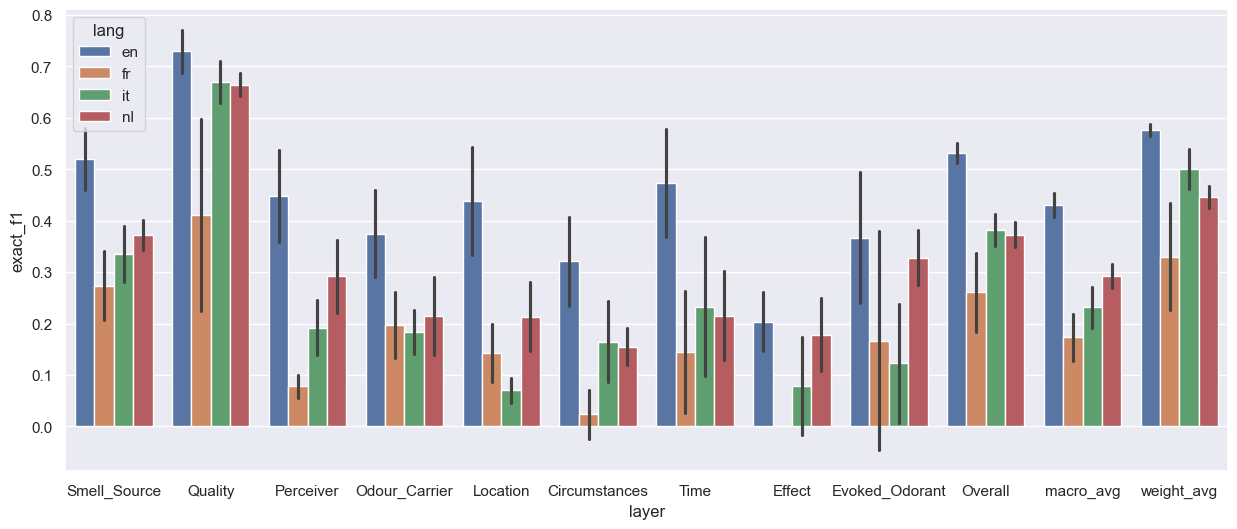

In [206]:
sns.set_theme()
ax = sns.barplot(folds_score, y='exact_f1', x='layer', hue='lang', errorbar='sd')
ax.figure.set_size_inches(15, 6)

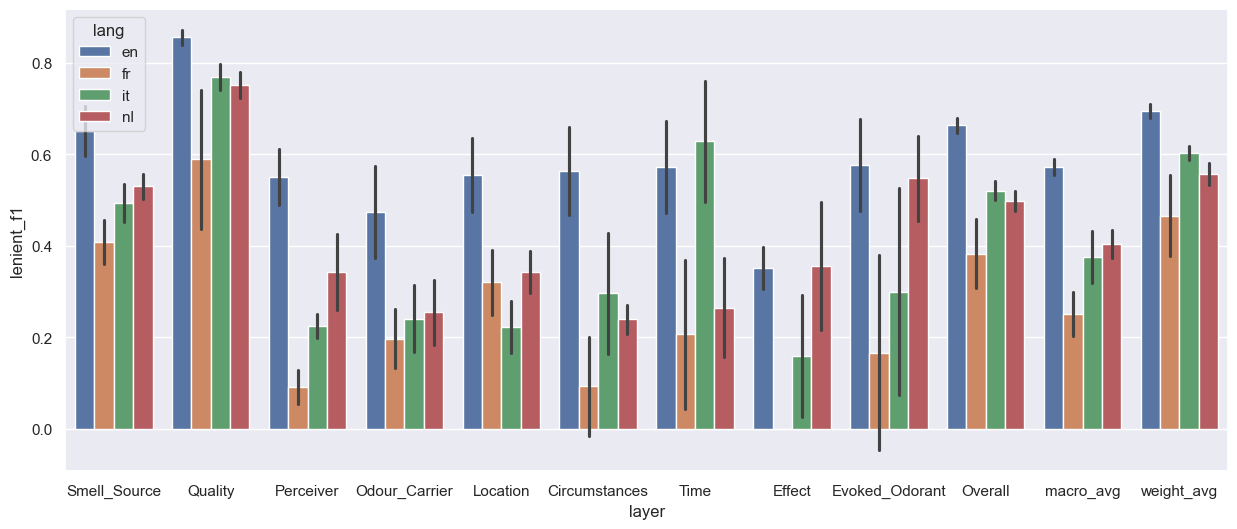

In [207]:
ax = sns.barplot(folds_score, y='lenient_f1', x='layer', hue='lang', errorbar='sd')
ax.figure.set_size_inches(15, 6)